In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
# 1. Load the California Housing dataset
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target  # Target is the median house value in $100,000s

In [4]:
# 2. Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
# 3. Initialize the Random Forest Regressor
# n_estimators: Number of trees in the forest
# max_depth: Limits the depth of trees to prevent overfitting
# n_jobs=-1: Uses all available processors for faster training
rf_regressor = RandomForestRegressor(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1)


In [6]:
# 4. Train the model
print("Training the model... (this may take a few seconds)")
rf_regressor.fit(X_train, y_train)

Training the model... (this may take a few seconds)


RandomForestRegressor(max_depth=20, n_jobs=-1, random_state=42)

In [7]:
# 5. Make predictions
y_pred = rf_regressor.predict(X_test)

In [8]:
# 6. Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\n--- Model Evaluation ---")
print(f"Mean Absolute Error (MAE): ${mae * 100000:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse * 100000:.2f}")
print(f"R² Score: {r2:.4f}")


--- Model Evaluation ---
Mean Absolute Error (MAE): $32793.02
Root Mean Squared Error (RMSE): $50583.28
R² Score: 0.8047


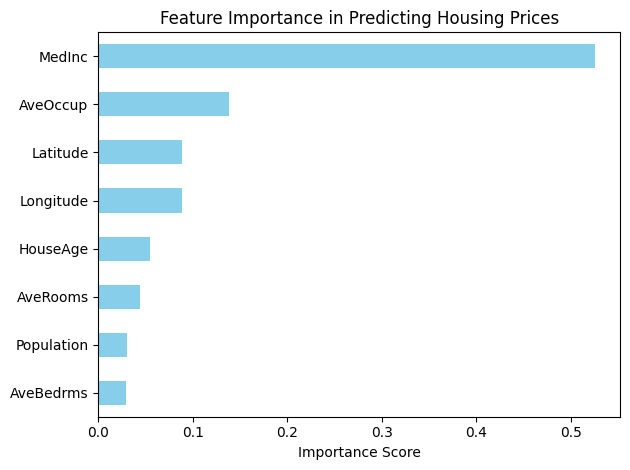

In [9]:
# 7. Visualize Feature Importance
importances = pd.Series(rf_regressor.feature_importances_, index=housing.feature_names)
importances.sort_values().plot(kind='barh', color='skyblue')
plt.title("Feature Importance in Predicting Housing Prices")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()